In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve,auc

In [3]:
df = pd.read_csv('framingham.csv')

In [4]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [6]:
df.drop(['education'], axis=1, inplace=True)

In [7]:
column_mapping = {
    'male': 'sex_male',
    'currentSmoker': 'current_smoker',
    'cigsPerDay': 'cigs_per_day',
    'BPMeds': 'bp_meds',
    'prevalentStroke': 'prevalent_stroke',
    'prevalentHyp': 'prevalent_hyp',
    'totChol': 'total_cholesterol',
    'sysBP': 'systolic_bp',
    'diaBP': 'diastolic_bp',
    'heartRate': 'heart_rate',
    'TenYearCHD': 'ten_year_chd'
}

df.rename(columns=column_mapping, inplace=True)

In [8]:
df.dropna(inplace=True)

In [9]:
X = df.drop('ten_year_chd', axis=1)
y = df['ten_year_chd']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
X_train

,sex_male,age,current_smoker,cigs_per_day,bp_meds,prevalent_stroke,prevalent_hyp,diabetes,total_cholesterol,systolic_bp,diastolic_bp,BMI,heart_rate,glucose
1386,0,53,0,0.0,0.0,0,0,0,234.0,126.0,73.0,27.60,75.0,90.0
2360,1,37,1,20.0,0.0,0,0,0,232.0,129.0,74.0,24.46,86.0,88.0
2908,0,59,1,9.0,0.0,0,0,0,229.0,127.5,76.0,23.65,74.0,70.0
991,1,39,1,30.0,0.0,0,0,0,199.0,124.0,86.0,23.39,76.0,72.0
3027,0,41,1,17.0,0.0,0,1,0,261.0,147.5,97.0,31.65,75.0,73.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,1,58,1,13.0,0.0,0,0,0,196.0,120.0,74.0,20.12,75.0,73.0
1449,1,37,1,30.0,0.0,0,0,0,275.0,127.0,80.0,27.22,85.0,93.0
963,0,42,1,9.0,0.0,0,0,0,218.0,109.5,67.0,23.48,65.0,71.0
3973,0,62,0,0.0,0.0,0,1,0,309.0,146.0,82.5,28.55,64.0,71.0


In [12]:
X_test

,sex_male,age,current_smoker,cigs_per_day,bp_meds,prevalent_stroke,prevalent_hyp,diabetes,total_cholesterol,systolic_bp,diastolic_bp,BMI,heart_rate,glucose
2435,1,36,1,20.0,0.0,0,0,0,155.0,127.5,77.5,30.20,56.0,61.0
1168,0,51,0,0.0,0.0,0,1,0,214.0,153.5,103.5,23.45,70.0,71.0
3761,0,60,1,5.0,0.0,0,1,0,246.0,160.0,92.0,26.38,80.0,73.0
496,1,51,1,13.0,0.0,0,0,0,245.0,137.0,76.0,22.26,83.0,73.0
3983,0,41,1,14.0,0.0,0,1,0,188.0,145.0,99.0,28.60,85.0,74.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,0,57,0,0.0,0.0,0,1,0,207.0,175.0,80.0,20.86,83.0,75.0
4142,1,47,1,20.0,0.0,0,1,0,234.0,162.0,110.0,27.51,80.0,85.0
1288,0,53,0,0.0,0.0,0,0,0,225.0,125.0,76.0,30.24,86.0,75.0
1054,1,58,1,60.0,0.0,0,1,0,250.0,150.0,97.0,32.00,75.0,65.0


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

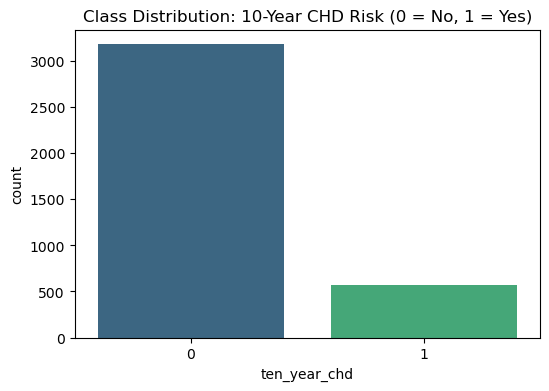

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='ten_year_chd', palette='viridis')
plt.title('Class Distribution: 10-Year CHD Risk (0 = No, 1 = Yes)')
plt.show()

In [15]:
print("Percentage of each class:")
print(round(df['ten_year_chd'].value_counts(normalize=True) * 100, 2))

Percentage of each class:
ten_year_chd
0    84.75
1    15.25
Name: proportion, dtype: float64


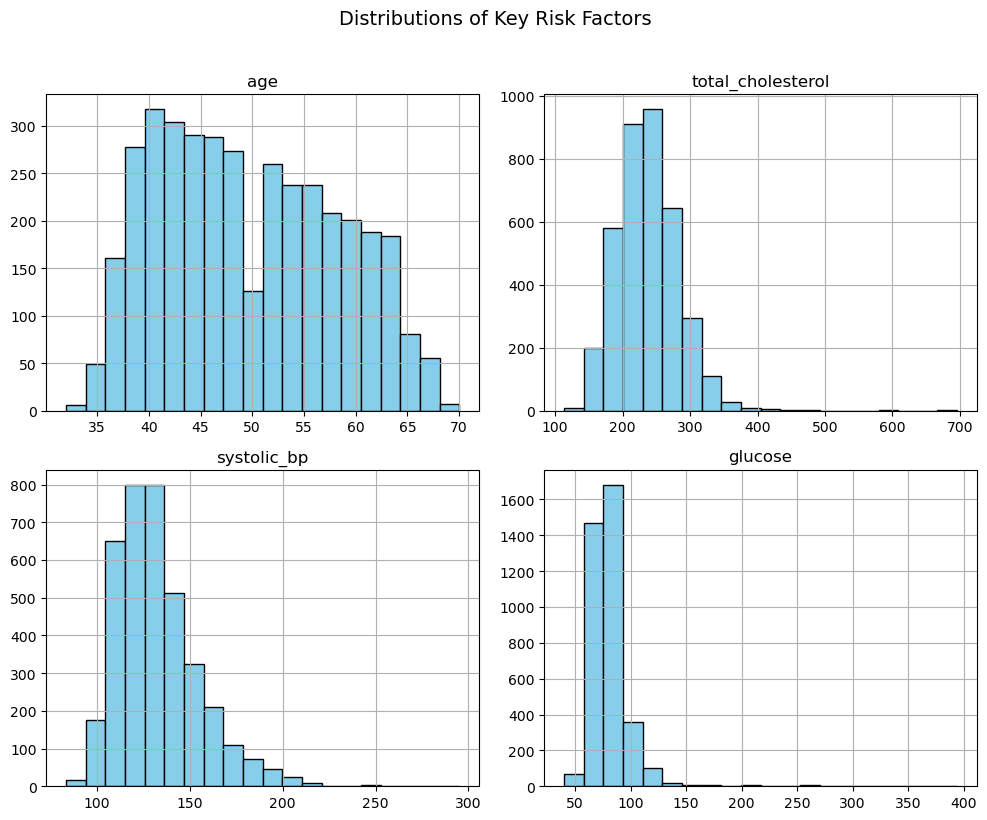

In [16]:
key_features = ['age', 'total_cholesterol', 'systolic_bp', 'glucose']

df[key_features].hist(figsize=(10, 8), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distributions of Key Risk Factors', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

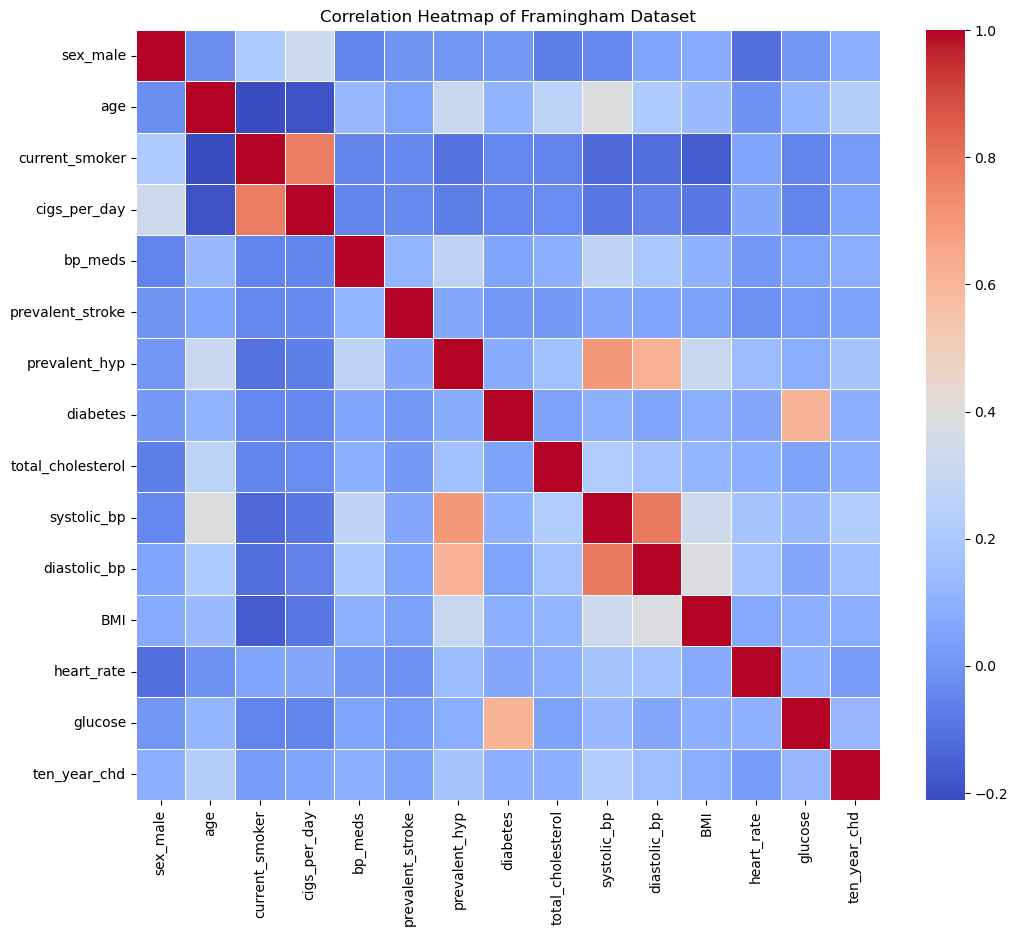

In [17]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Framingham Dataset')
plt.show()

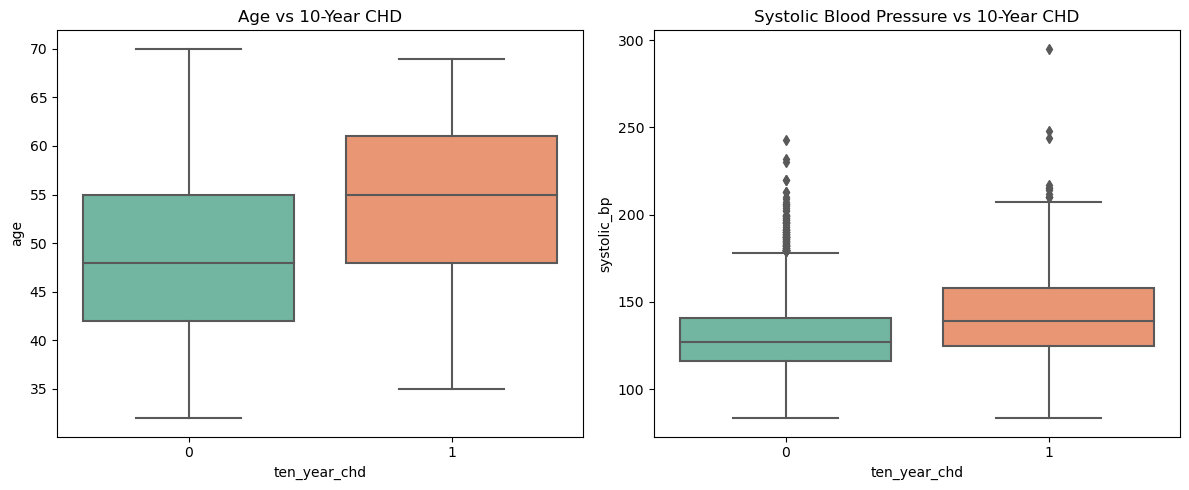

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='ten_year_chd', y='age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Age vs 10-Year CHD')

sns.boxplot(x='ten_year_chd', y='systolic_bp', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Systolic Blood Pressure vs 10-Year CHD')

plt.tight_layout()
plt.show()

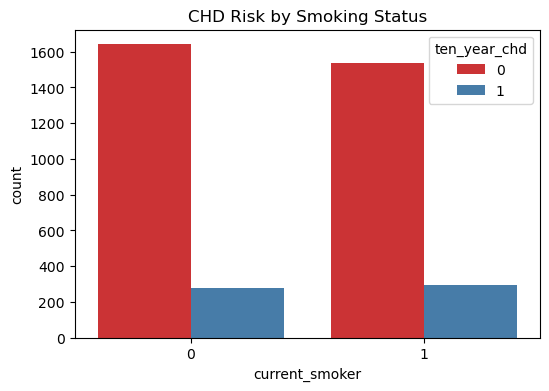

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='current_smoker', hue='ten_year_chd', palette='Set1')
plt.title('CHD Risk by Smoking Status')
plt.show()

In [20]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
y_pred = lr.predict(X_test_scaled)
y_pred_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [22]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")

Accuracy Score: 0.8339



In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       938
           1       0.52      0.07      0.12       188

    accuracy                           0.83      1126
   macro avg       0.68      0.53      0.52      1126
weighted avg       0.79      0.83      0.78      1126



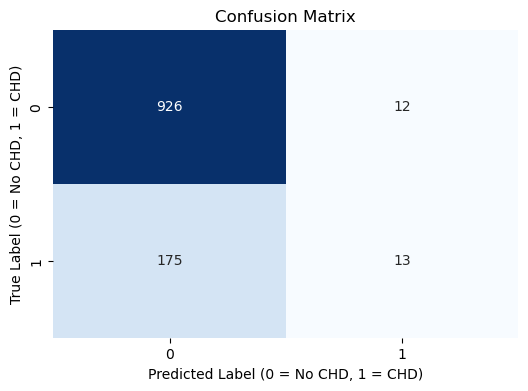

In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label (0 = No CHD, 1 = CHD)')
plt.ylabel('True Label (0 = No CHD, 1 = CHD)')
plt.show()

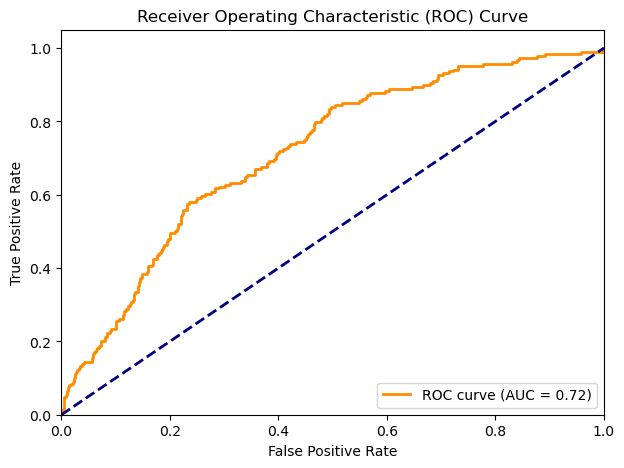

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## The likelihood of heart disease in new patient data

In [29]:
new_patient_data = pd.DataFrame([{
    'sex_male': 1,
    'age': 55,                   
    'current_smoker': 1,
    'cigs_per_day': 20,          
    'bp_meds': 0,
    'prevalent_stroke': 0,
    'prevalent_hyp': 1,
    'diabetes': 0,
    'total_cholesterol': 260,    
    'systolic_bp': 140,          
    'diastolic_bp': 90,          
    'BMI': 28.5,                 
    'heart_rate': 75,            
    'glucose': 85                
}])

In [30]:
new_patient_scaled = scaler.transform(new_patient_data)

In [32]:
prediction = lr.predict(new_patient_scaled)
probability = lr.predict_proba(new_patient_scaled)[0][1]

print(f"CHD Risk Prediction: {'High Risk (1)' if prediction[0] == 1 else 'Low Risk (0)'}")
print(f"Probability of developing CHD in 10 years: {probability * 100:.2f}%")

CHD Risk Prediction: Low Risk (0)
Probability of developing CHD in 10 years: 31.02%
